Since the SHO is a second order equation, I need to return the equations for both the first derivative and the second derivative.

For the majority of the code in the following block, I coppied and modified the code I wrote at the end of Workbook 3.2.


## Damped Analytic Solutons
Solve the differential equation
```math
\ddot{x} + \gamma \dot{x} + \omega^2 x = 0
```

The general solution is
```math
x(t) = e^{-\gamma t/2} \left(C_1 e^{i\omega_d t} + C_2 e^{-i\omega_d t}\right)
```

where
```math
\omega_d = \sqrt{\omega^2 - \frac{\gamma^2}{4}}
```

Applying the initial conditions
```math
x(0) = x_0, \quad v(0) = v_0
```

gives
```math
C_1 = \frac{v_0 - r_2 x_0}{r_1 - r_2}, \quad
C_2 = \frac{r_1 x_0 - v_0}{r_1 - r_2}
```

with
```math
r_{1,2} = -\frac{\gamma}{2} \pm i\omega_d
```

### Math vs Code
The math is easier using complex numbers and complex exponentials, but that means it won't very straightforward to calculate and plot. So I have a choice of either breaking into sines and cosines to make it one level simpler to plot, or leaving it in complex and then taking the real part to plot. I went with the second method so that the writeup is a little more straight forward. 

### Velocity
Now that we have an analytic solution for position, just take the derivative for velocity

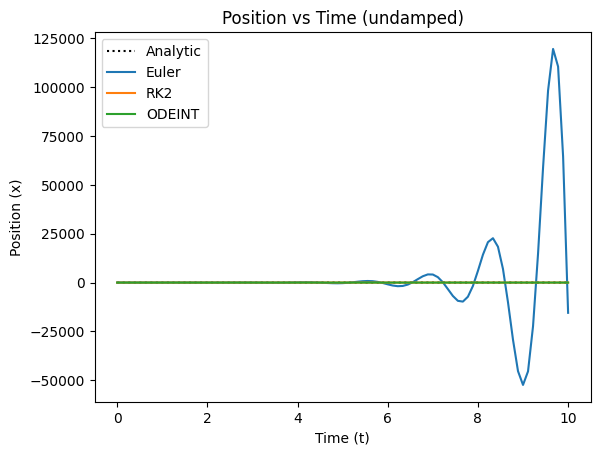

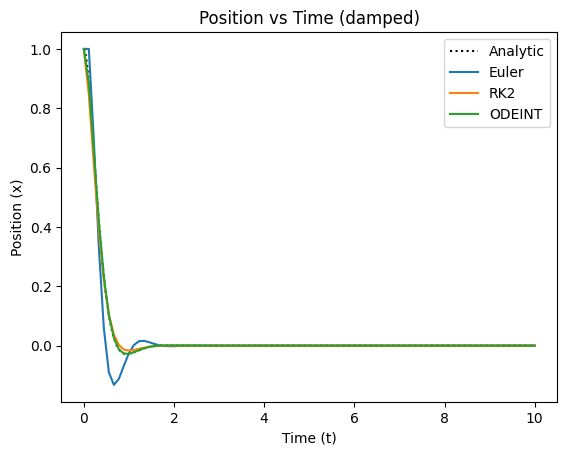

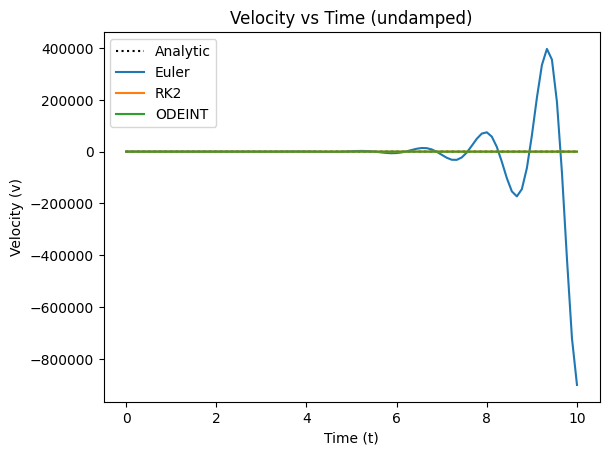

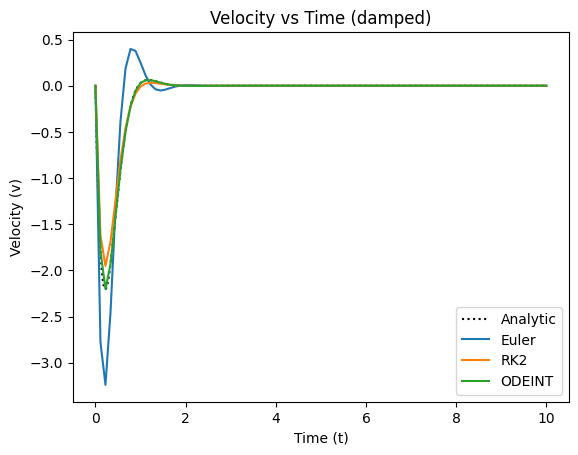

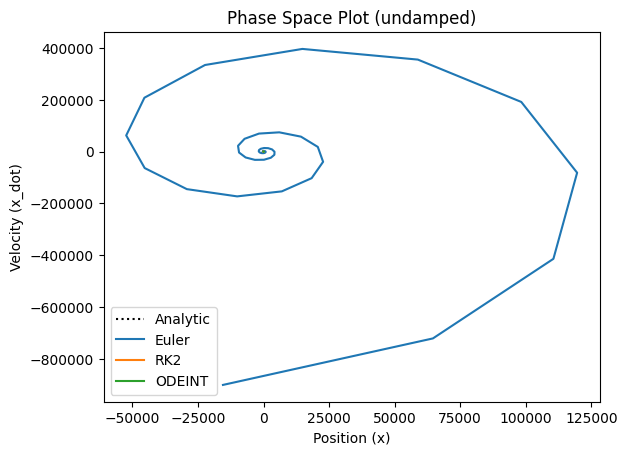

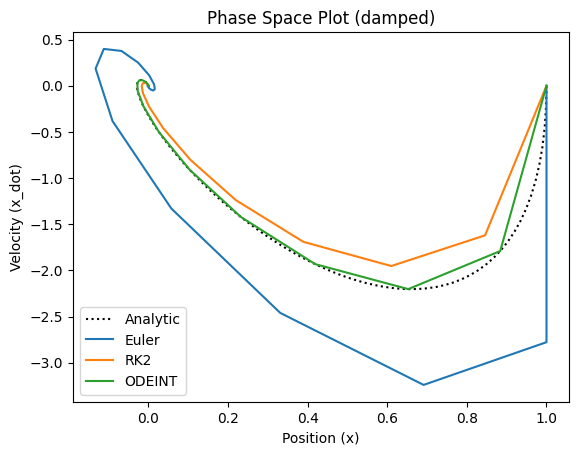

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

##################################################
# CONSTANTS
##################################################
x0         = 1.0            # Initial position
v0         = 0.0            # Initial velocity
coord_init = [x0, v0]
omega      = 5              # Natural frequency
gamma      = 1.5 * omega    # Damping coefficient
tmin       = 0.0            # Start time
tmax       = 10.0           # End time
nts        = 90             # Number of points

##################################################
# DE FUNCTIONS
##################################################
####
# I will use coordinate notation for position and velocity
# so that the point can be plotted in phase space [coord[0], coord[1]]
# and so that it can be passed to the solvers cleanly
####
#------------------------------------------------
# SHO DE
#  x¨+ω²x=0
#  omega = sqrt(k/m)
#------------------------------------------------
def sho(coord, t):
    x         = coord[0]
    v         = coord[1]
    x_dot     = v
    x_dot_dot = -omega**2 * x
    return np.array([x_dot, x_dot_dot])     ## Needed to make this an array so I can multiply stuff later on - clears an error

#------------------------------------------------
# DAMPED SHO DE
#   mx¨+bx˙+kx=0  --> x¨+γx˙+ω²x=0
#   gamma = b/m and omega = sqrt(k/m)
#------------------------------------------------
def damped_sho(coord, t):
    x         = coord[0]
    v         = coord[1]
    x_dot     = v
    x_dot_dot = -(omega**2 * x) - (gamma*v)
    return np.array([x_dot, x_dot_dot])


##################################################
# SOLVERS
##################################################
#------------------------------------------------
# RESTATEMENT: EULER SOLVER
#------------------------------------------------
def Euler_solver(coord_init, tmin, tmax, nts, deriv):
    coord = np.zeros((nts+1, 2))              #This is a 2D array to hold both position and velocity
        # Very annoying bug to fix here with my np.zeros function needing a single input but the array needing to be 2D
    coord[0] = coord_init
    t   = np.linspace(tmin, tmax, nts+1)
    dt  = t[1] - t[0]

    for it in range(0, nts):
        coord_deriv = deriv(coord[it], t[it])
        coord[it+1] = coord[it] + dt * coord_deriv

    return t, coord

#------------------------------------------------
# RESTATEMENT: RK2 SOLVER
#------------------------------------------------
def RK2_solver(coord_init, tmin, tmax, nts, deriv):
    # Modeled after the Euler Solver above
    coord    = np.zeros((nts+1, 2))
    coord[0] = coord_init
    t        = np.linspace(tmin, tmax, nts+1)
    dt       = t[1] - t[0]

    for it in range(0, nts):        # This was just modified based on the function from nb 3.2
        coord_deriv_half = deriv(coord[it], t[it])
        coord_half       = coord[it] + (dt/2 * coord_deriv_half)
        coord_deriv      = deriv(coord_half, (t[it] + dt/2))
        coord[it+1]      = coord[it] + (dt * coord_deriv)

    return t, coord

#------------------------------------------------
# ODEINT SOVLER
#------------------------------------------------
def diffeq_solver_from_scipy(coord_init, tmin, tmax, nts, deriv):
    t = np.linspace(tmin, tmax, nts+1)
    coord = odeint(deriv, coord_init, t)
    return t, coord



##################################################
# CALL FUNCTIONS - STORE RESULTS
    # Side note: The functions return a matrix of sorts. The first column is position, second column is velocity
    # To extract it the syntax is [row, column] => [all rows, specific column] => [:, 0 or 1]

    # Another side note: Yes, t is overwritten but it is 
    # just overwritten with a matching array so its fine, see below
##################################################
#------------------------------------------------
# Undamped
#------------------------------------------------
t, coord_euler = Euler_solver(coord_init, tmin, tmax, nts, sho)
x_euler = coord_euler[:, 0]
v_euler = coord_euler[:, 1]

t, coord_rk2 = RK2_solver(coord_init, tmin, tmax, nts, sho)
x_rk2 = coord_rk2[:, 0]
v_rk2 = coord_rk2[:, 1]

t, coord_odeint = diffeq_solver_from_scipy(coord_init, tmin, tmax, nts, sho)
x_odeint = coord_odeint[:, 0]
v_odeint = coord_odeint[:, 1]

# Analytic solution  
t_exact = np.linspace(tmin, tmax, 50)
x_exact = (x0 * np.cos(omega*t_exact)) + ((v0/omega) * np.sin(omega*t_exact))
v_exact = -x0*omega*np.sin(omega*t_exact) + v0*np.cos(omega*t_exact)

#------------------------------------------------
# Damped
#------------------------------------------------
t, coord_euler = Euler_solver(coord_init, tmin, tmax, nts, damped_sho)
x_euler_damped = coord_euler[:, 0]
v_euler_damped = coord_euler[:, 1]

t, coord_rk2 = RK2_solver(coord_init, tmin, tmax, nts, damped_sho)
x_rk2_damped = coord_rk2[:, 0]
v_rk2_damped = coord_rk2[:, 1]

t, coord_odeint = diffeq_solver_from_scipy(coord_init, tmin, tmax, nts, damped_sho)
x_odeint_damped = coord_odeint[:, 0]
v_odeint_damped = coord_odeint[:, 1]

#*******************************************************************************************************************************************************************
#*******************************************************************************************************************************************************************
t_exact_damped = np.linspace(tmin, tmax, 1000)

# Analytic solution: Some work needs done to understand this...
    # Please refer to the top section markdown for a breif 
    # coverage of why I am about to calculate all these things
omega_d = np.sqrt(omega**2 - (gamma**2)/4)
r1 = -gamma/2 + 1j*omega_d      # 1j in python is the sqrt(-1) or 'i'
r2 = -gamma/2 - 1j*omega_d
C1 = (v0 - r2*x0) / (r1 - r2)
C2 = (r1*x0 - v0) / (r1 - r2)

x_complex_damped = (C1 * np.exp(r1 * t_exact_damped)) + (C2 * np.exp(r2 * t_exact_damped))              # I say x_complex because this is a complex exponetial. 
x_exact_damped   = np.real(x_complex_damped)                                                            # To plot it, I will need to take the real component
v_complex_damped = (C1 * r1 * np.exp(r1 * t_exact_damped)) + (C2 * r2 * np.exp(r2 * t_exact_damped))    # Just the derivative of x
v_exact_damped   = np.real(v_complex_damped)
#*******************************************************************************************************************************************************************
#*******************************************************************************************************************************************************************


##################################################
# PLOTS
##################################################
#------------------------------------------------
# POSITION VS TIME PLOTS
#------------------------------------------------
# Undamped
plt.figure()
plt.plot(t_exact, x_exact, 'k:', label="Analytic")
plt.plot(t, x_euler, label="Euler")
plt.plot(t, x_rk2, label="RK2")
plt.plot(t, x_odeint, label="ODEINT")
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.title("Position vs Time (undamped)")
plt.legend()
plt.show()

# Damped
plt.figure()
plt.plot(t_exact_damped, x_exact_damped, 'k:', label="Analytic")
plt.plot(t, x_euler_damped, label="Euler")
plt.plot(t, x_rk2_damped, label="RK2")
plt.plot(t, x_odeint_damped, label="ODEINT")
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.title("Position vs Time (damped)")
plt.legend()
plt.show()

#------------------------------------------------
# VELOCITY VS TIME PLOTS
#------------------------------------------------
# Undamped
plt.figure()
plt.plot(t_exact, v_exact, 'k:', label="Analytic")
plt.plot(t, v_euler, label="Euler")
plt.plot(t, v_rk2, label="RK2")
plt.plot(t, v_odeint, label="ODEINT")
plt.xlabel('Time (t)')
plt.ylabel('Velocity (v)')
plt.title("Velocity vs Time (undamped)")
plt.legend()
plt.show()

# Damped
plt.figure()
plt.plot(t_exact_damped, v_exact_damped, 'k:', label="Analytic")
plt.plot(t, v_euler_damped, label="Euler")
plt.plot(t, v_rk2_damped, label="RK2")
plt.plot(t, v_odeint_damped, label="ODEINT")
plt.xlabel('Time (t)')
plt.ylabel('Velocity (v)')
plt.title("Velocity vs Time (damped)")
plt.legend()
plt.show()

#------------------------------------------------
# PHASE SPACE PLOT
#   v vs x instead of p vs x
#------------------------------------------------
# Undamped
plt.figure()
plt.plot(x_exact, v_exact, 'k:', label="Analytic")
plt.plot(x_euler, v_euler, label="Euler")
plt.plot(x_rk2, v_rk2, label="RK2")
plt.plot(x_odeint, v_odeint, label="ODEINT")
plt.xlabel('Position (x)')
plt.ylabel('Velocity (x_dot)')
plt.title('Phase Space Plot (undamped)')
plt.legend()
plt.show()

# Damped
plt.figure()
plt.plot(x_exact_damped, v_exact_damped, 'k:', label="Analytic")
plt.plot(x_euler_damped, v_euler_damped, label="Euler")
plt.plot(x_rk2_damped, v_rk2_damped, label="RK2")
plt.plot(x_odeint_damped, v_odeint_damped, label="ODEINT")
plt.xlabel('Position (x)')
plt.ylabel('Velocity (x_dot)')
plt.title('Phase Space Plot (damped)')
plt.legend()
plt.show()


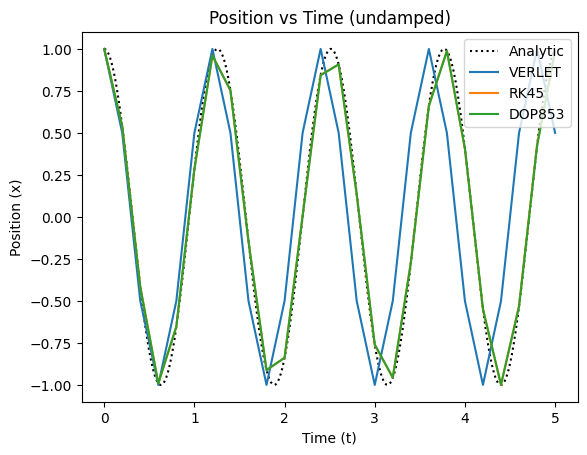

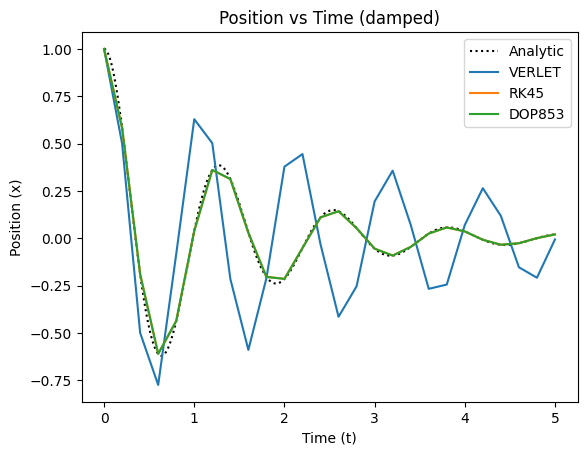

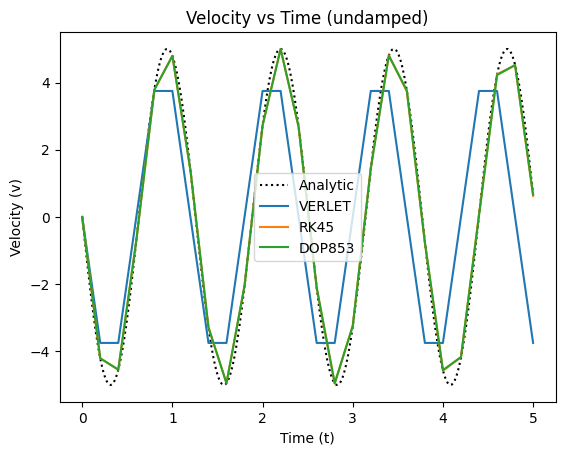

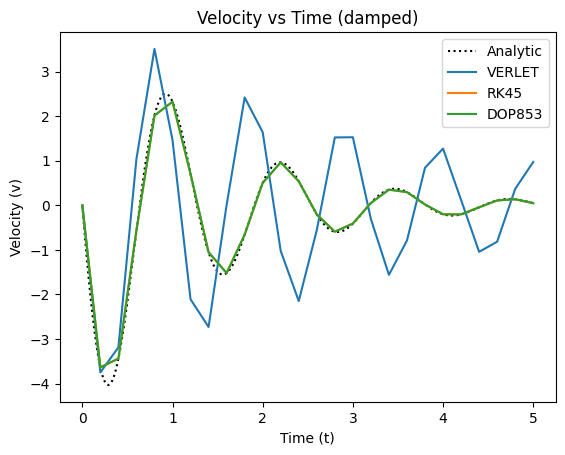

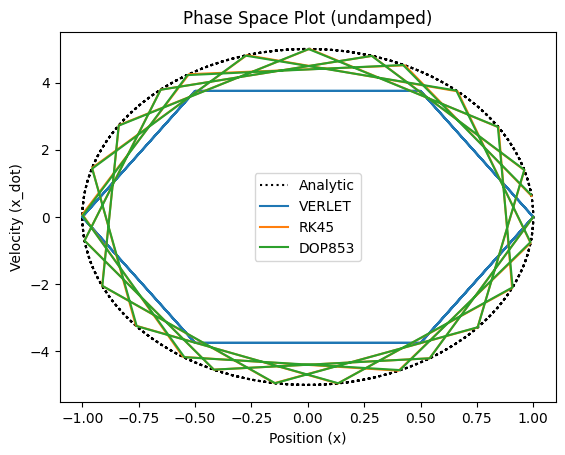

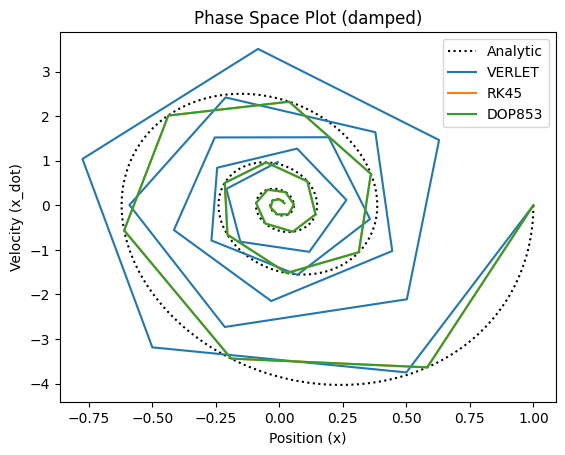

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

##################################################
# CONSTANTS
##################################################
x0         = 1.0            # Initial position
v0         = 0.0            # Initial velocity
coord_init = [x0, v0]
omega      = 5              # Natural frequency
gamma      = 0.3 * omega    # Damping coefficient
tmin       = 0.0            # Start time
tmax       = 5.0            # End time
nts        = 25             # Number of points

##################################################
# DE FUNCTIONS
##################################################
####
# I will use coordinate notation for position and velocity
# so that the point can be plotted in phase space [coord[0], coord[1]]
# and so that it can be passed to the solvers cleanly
####
#------------------------------------------------
# SHO DE
#  x¨+ω²x=0
#  omega = sqrt(k/m)
#------------------------------------------------
def sho(coord, t):
    x         = coord[0]
    v         = coord[1]
    x_dot     = v
    x_dot_dot = -omega**2 * x
    return np.array([x_dot, x_dot_dot]) 
    ## Needed to make this an array so I can multiply stuff later on - clears an error

#------------------------------------------------
# DAMPED SHO DE
#   mx¨+bx˙+kx=0  --> x¨+γx˙+ω²x=0
#   gamma = b/m and omega = sqrt(k/m)
#------------------------------------------------
def damped_sho(coord, t):
    x         = coord[0]
    v         = coord[1]
    x_dot     = v
    x_dot_dot = -(omega**2 * x) - (gamma*v)
    return np.array([x_dot, x_dot_dot])



##################################################
# SYMPLETIC ALGORITHM - VERLET INTEGRATOR
#   https://en.wikipedia.org/wiki/Verlet_integration
#   Still just pass the initial position and 
#       velocity to the function. We will include 
#       accleration in the final array.
##################################################
def Verlet_solver(coord_init, tmin, tmax, nts, deriv):
    t        = np.linspace(tmin, tmax, nts+1)
    dt       = t[1] - t[0]    
    coord    = np.zeros((nts+1, 3))     # Since Verlet tracts position and acceleration, lets tract x, v, and a wiht a 3D array

    # I need to find the inital acceleration from the derive funciton
    temp_a   = deriv(coord_init, t[0])
    a0       = temp_a[1]
    coord[0] = [coord_init[0], coord_init[1], a0]       # [x0, v0, a0]

    # Main loop
    for it in range(0, nts):
        # Extract x, v, a so that we can use them in calculations
        x, v, a = coord[it]

        # Update position
        x_future = x + (v*dt) + (0.5*a * dt**2)  
        
        # Update acceleration
        # I need to calculate acc to find the updated velocity
        # To calculate the acc, I call the deriv func with future x, current v, and future t
        temp_a_future = deriv([x_future, v], t[it+1])
        a_future      = temp_a_future[1]

        # Update velocity
        # The Verlet method uses the average acceleration over the time step
        v_future = v + (0.5 * (a + a_future) * dt)

        # Store the future values in the array
        coord[it+1] = [x_future, v_future, a_future]

    return t, coord

##################################################
# ADDITIONAL FUNCTIONS (RK4 AND DOP853)
##################################################
#------------------------------------------------
# RK45 SOLVER
# Take a look at the return types: https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html
#------------------------------------------------
def RK45_solver(coord_init, tmin, tmax, nts, deriv):
    t = np.linspace(tmin, tmax, nts+1)

    # The functions from SciPy expect the arguments in the opposite order 
    # (coord, t instead of t, coord). So I make a function to swap it
    def swapped_deriv(t, coord):
        return deriv(coord, t)
    sol = solve_ivp(swapped_deriv, (tmin, tmax), coord_init, t_eval=t, method='RK45')
    return sol.t, sol.y.T  
    # sol.y.T in plain english means "take the solution array and swap the rows and columns". 
    # solve_ivp returns an array where each column is a variable (x or v) and each row is a time step
    # Unfortunately, I defined my other function the other-way-around and I want this one to match  (rows are time steps, columns are x and v)

#------------------------------------------------
# DOP853 SOLVER
#   Most of the same comments in RK45 apply to this function too...
#------------------------------------------------
def DOP853_solver(coord_init, tmin, tmax, nts, deriv):
    t = np.linspace(tmin, tmax, nts+1)

    def swapped_deriv(t, coord):
        return deriv(coord, t)
    
    sol = solve_ivp(swapped_deriv, (tmin, tmax), coord_init, t_eval=t, method='DOP853')
    return sol.t, sol.y.T  



##################################################
# CALL FUNCTIONS - STORE RESULTS
##################################################
#------------------------------------------------
# Undamped
#------------------------------------------------
t, coord_Verlet = Verlet_solver(coord_init, tmin, tmax, nts, sho)
x_Verlet = coord_Verlet[:, 0]
v_Verlet = coord_Verlet[:, 1]

t, coord_RK45 = RK45_solver(coord_init, tmin, tmax, nts, sho)
x_RK45 = coord_RK45[:, 0]
v_RK45 = coord_RK45[:, 1]

t, coord_DOP853 = DOP853_solver(coord_init, tmin, tmax, nts, sho)
x_DOP853 = coord_DOP853[:, 0]
v_DOP853 = coord_DOP853[:, 1]

# Analytic solution  
t_exact = np.linspace(tmin, tmax, 10000)
x_exact = (x0 * np.cos(omega*t_exact)) + ((v0/omega) * np.sin(omega*t_exact))
v_exact = -x0*omega*np.sin(omega*t_exact) + v0*np.cos(omega*t_exact)

#------------------------------------------------
# Damped
#------------------------------------------------
t, coord_Verlet_damped = Verlet_solver(coord_init, tmin, tmax, nts, damped_sho)
x_Verlet_damped = coord_Verlet_damped[:, 0]
v_Verlet_damped = coord_Verlet_damped[:, 1]

t, coord_RK45_damped = RK45_solver(coord_init, tmin, tmax, nts, damped_sho)
x_RK45_damped = coord_RK45_damped[:, 0]
v_RK45_damped = coord_RK45_damped[:, 1]

t, coord_DOP853_damped = DOP853_solver(coord_init, tmin, tmax, nts, damped_sho)
x_DOP853_damped = coord_DOP853_damped[:, 0]
v_DOP853_damped = coord_DOP853_damped[:, 1]

#*******************************************************************************************************************************************************************
#*******************************************************************************************************************************************************************
t_exact_damped = np.linspace(tmin, tmax, 10000)

# Analytic solution: Some work needs done to understand this...
    # Please refer to the top section markdown for a breif 
    # coverage of why I am about to calculate all these things
omega_d = np.sqrt(omega**2 - (gamma**2)/4)
r1 = -gamma/2 + 1j*omega_d      # 1j in python is the sqrt(-1) or 'i'
r2 = -gamma/2 - 1j*omega_d
C1 = (v0 - r2*x0) / (r1 - r2)
C2 = (r1*x0 - v0) / (r1 - r2)

x_complex_damped = (C1 * np.exp(r1 * t_exact_damped)) + (C2 * np.exp(r2 * t_exact_damped))              # I say x_complex because this is a complex exponetial. 
x_exact_damped   = np.real(x_complex_damped)                                                            # To plot it, I will need to take the real component
v_complex_damped = (C1 * r1 * np.exp(r1 * t_exact_damped)) + (C2 * r2 * np.exp(r2 * t_exact_damped))    # Just the derivative of x
v_exact_damped   = np.real(v_complex_damped)
#*******************************************************************************************************************************************************************
#*******************************************************************************************************************************************************************


##################################################
# PLOTS
##################################################
#------------------------------------------------
# POSITION VS TIME PLOTS
#------------------------------------------------
# Undamped
plt.figure()
plt.plot(t_exact, x_exact, 'k:', label="Analytic")
plt.plot(t, x_Verlet, label="VERLET")
plt.plot(t, x_RK45, label="RK45")
plt.plot(t, x_DOP853, label="DOP853")
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.title("Position vs Time (undamped)")
plt.legend()
plt.show()

# Damped
plt.figure()
plt.plot(t_exact_damped, x_exact_damped, 'k:', label="Analytic")
plt.plot(t, x_Verlet_damped, label="VERLET")
plt.plot(t, x_RK45_damped, label="RK45")
plt.plot(t, x_DOP853_damped, label="DOP853")
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.title("Position vs Time (damped)")
plt.legend()
plt.show()

#------------------------------------------------
# VELOCITY VS TIME PLOTS
#------------------------------------------------
# Undamped
plt.figure()
plt.plot(t_exact, v_exact, 'k:', label="Analytic")
plt.plot(t, v_Verlet, label="VERLET")
plt.plot(t, v_RK45, label="RK45")
plt.plot(t, v_DOP853, label="DOP853")
plt.xlabel('Time (t)')
plt.ylabel('Velocity (v)')
plt.title("Velocity vs Time (undamped)")
plt.legend()
plt.show()

# Damped
plt.figure()
plt.plot(t_exact_damped, v_exact_damped, 'k:', label="Analytic")
plt.plot(t, v_Verlet_damped, label="VERLET")
plt.plot(t, v_RK45_damped, label="RK45")
plt.plot(t, v_DOP853_damped, label="DOP853")
plt.xlabel('Time (t)')
plt.ylabel('Velocity (v)')
plt.title("Velocity vs Time (damped)")
plt.legend()
plt.show()

#------------------------------------------------
# PHASE SPACE PLOT
#   v vs x instead of p vs x
#------------------------------------------------
# Undamped
plt.figure()
plt.plot(x_exact, v_exact, 'k:', label="Analytic")
plt.plot(x_Verlet, v_Verlet, label="VERLET")
plt.plot(x_RK45, v_RK45, label="RK45")
plt.plot(x_DOP853, v_DOP853, label="DOP853")
plt.xlabel('Position (x)')
plt.ylabel('Velocity (x_dot)')
plt.title('Phase Space Plot (undamped)')
plt.legend()
plt.show()

# Damped
plt.figure()
plt.plot(x_exact_damped, v_exact_damped, 'k:', label="Analytic")
plt.plot(x_Verlet_damped, v_Verlet_damped, label="VERLET")
plt.plot(x_RK45_damped, v_RK45_damped, label="RK45")
plt.plot(x_DOP853_damped, v_DOP853_damped, label="DOP853")
plt.xlabel('Position (x)')
plt.ylabel('Velocity (x_dot)')
plt.title('Phase Space Plot (damped)')
plt.legend()
plt.show()



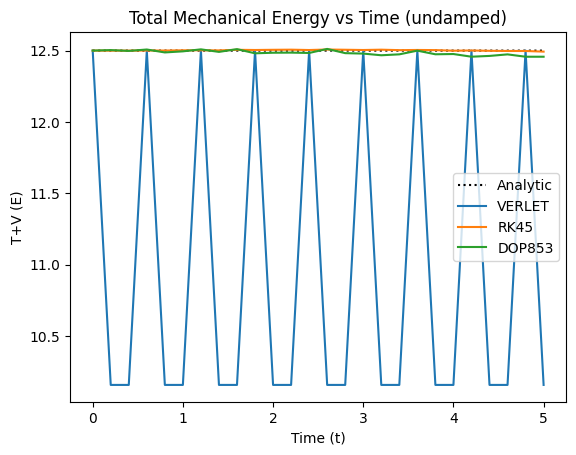

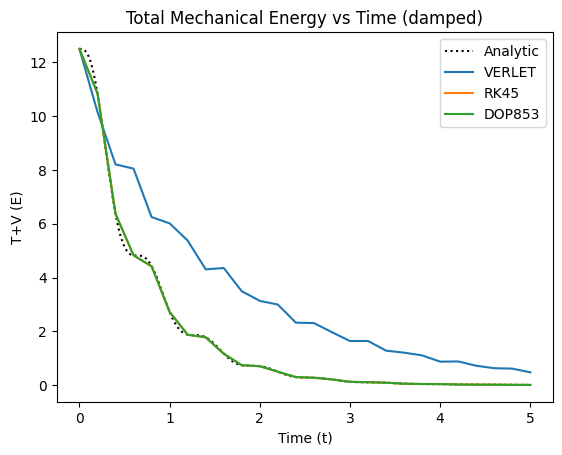

In [19]:
##################################################
# ENERGY PLOTS
##################################################
#------------------------------------------------
# Calculate energy
#   T = 0.5 * m * v**2 
#   V = 0.5 * k * x**2 
#   SET m = 1:
#       T = 0.5 * v**2
#       V = 0.5 * omega**2 * x**2
#------------------------------------------------
def calc_energy(x, v, omega):
    T = 0.5 * v**2
    V = 0.5 * omega**2 * x**2
    return T + V

#------------------------------------------------
# Undamped
#------------------------------------------------
E_Verlet = calc_energy(x_Verlet, v_Verlet, omega)
E_RK45   = calc_energy(x_RK45,   v_RK45,   omega)
E_DOP853 = calc_energy(x_DOP853, v_DOP853, omega)
E_exact  = calc_energy(x_exact,  v_exact,  omega)

#------------------------------------------------
# Damped
#------------------------------------------------
E_Verlet_damped = calc_energy(x_Verlet_damped, v_Verlet_damped, omega)
E_RK45_damped   = calc_energy(x_RK45_damped,   v_RK45_damped,   omega)
E_DOP853_damped = calc_energy(x_DOP853_damped, v_DOP853_damped, omega)
E_exact_damped  = calc_energy(x_exact_damped,  v_exact_damped,  omega)

#------------------------------------------------
# Undamped Energy Plot
#------------------------------------------------
plt.figure()
plt.plot(t_exact, E_exact, 'k:', label="Analytic")
plt.plot(t, E_Verlet, label="VERLET")
plt.plot(t, E_RK45, label="RK45")
plt.plot(t, E_DOP853, label="DOP853")
plt.xlabel('Time (t)')
plt.ylabel('T+V (E)')
plt.title("Total Mechanical Energy vs Time (undamped)")
plt.legend()
plt.show()

#------------------------------------------------
# Damped Energy Plot
#------------------------------------------------
plt.figure()
plt.plot(t_exact_damped, E_exact_damped, 'k:', label="Analytic")
plt.plot(t, E_Verlet_damped, label="VERLET")
plt.plot(t, E_RK45_damped, label="RK45")
plt.plot(t, E_DOP853_damped, label="DOP853")
plt.xlabel('Time (t)')
plt.ylabel('T+V (E)')
plt.title("Total Mechanical Energy vs Time (damped)")
plt.legend()
plt.show()